In [2]:
import pandas as pd
import numpy as np
from glob import glob
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import MaxNLocator
from statsmodels.stats.multicomp import pairwise_tukeyhsd
warnings.filterwarnings("ignore")

# Data preparation

In [3]:
def reformat_dataframe(df):
    reformat_df = df.melt(id_vars=['Image', 'Name', 'Class', 
                    'Parent', 'ROI', 'Centroid X µm',
                    'Centroid Y µm'], 
                    var_name='measuremnt',
                    value_name='value').dropna(subset=['value'])
    return reformat_df

In [4]:
path = '/Volumes/lab-kohlj/home/shared/people/Mingran/NPS_imaging/HCN_RNAscope/detection_results'
all_files = glob(path + '/*.tsv')
# all_df = pd.DataFrame()

# File to keep track of processed files
processed_files_log = 'processed_files.txt'

# Load set of already processed files if the log exists
try:
    with open(processed_files_log, 'r') as f:
        processed_files = set(f.read().splitlines())
except FileNotFoundError:
    processed_files = set()

dfs = []
for file in tqdm(all_files, desc='Processing files'):
    if file not in processed_files:
        df = pd.read_csv(file, sep='\t')
        reformat_df = reformat_dataframe(df)
        dfs.append(reformat_df)
        
        # Log this file as processed
        with open(processed_files_log, 'a') as f:
            f.write(file + '\n')

# Concatenate all DataFrames at once after processing
all_df = pd.concat(dfs)

Processing files: 100%|██████████| 152/152 [00:00<00:00, 1142534.42it/s]


ValueError: No objects to concatenate

In [30]:
all_df.to_csv('all_detection_results.csv', index=False)

# Data Analysis

In [5]:
estrous_df = pd.read_csv('MC_RNAscope_estrous.csv')
estrous_df['mice_ID'] = estrous_df['mice_ID'].str.lower()
detections = pd.read_csv('all_detection_results_original.csv')

In [6]:
kept_measurements = ['Subcellular: Channel 2: Num spots estimated',
                     'Subcellular: Channel 2: Num single spots',
                     'Subcellular: Channel 2: Num clusters',
                     'Subcellular: Channel 3: Num spots estimated',
                     'Subcellular: Channel 3: Num single spots',
                     'Subcellular: Channel 3: Num clusters',
                     'Subcellular: Channel 4: Num spots estimated',
                     'Subcellular: Channel 4: Num single spots',
                     'Subcellular: Channel 4: Num clusters',
                     'Subcellular: Channel 5: Num spots estimated',
                     'Subcellular: Channel 5: Num single spots',
                     'Subcellular: Channel 5: Num clusters', 'Num spots']

filtered_detections = detections[(detections['Name']== 'PathCellObject') &
                                 (detections['measuremnt'].isin(kept_measurements))]

spot_detection = filtered_detections[filtered_detections['measuremnt'].str.contains('Num spots estimated')]
spot_detection['channel'] = spot_detection['measuremnt'].str.extract(r'Channel (\d)')
channel_mapping = {'2': 'HCN1', '3': 'HCN2', '4': 'HCN3', '5': 'HCN4'}
spot_detection['channel'] = spot_detection['channel'].map(channel_mapping)
spot_detection['mice_ID'] = spot_detection['Image'].str.split('_').str[0].str.lower()


In [7]:
merged_df = pd.merge(spot_detection, estrous_df, on='mice_ID', how='left')
# merged_df = merged_df[merged_df['Unmix Batch'] != '1']
# merged_df = merged_df[merged_df['value']< 250]
# result = merged_df.groupby(['estrous_stage' ,'mice_ID', 'channel'])['value'].mean().reset_index()
# result['estrous_stage'] = pd.Categorical(result['estrous_stage'], categories=['P', 'E', 'M', 'D'], ordered=True)

In [8]:
# calculate the upper 90% confidence interval
def ci90(x):
    return x.quantile(0.90)

oversaturate = merged_df.groupby(['Unmix Batch', 'channel'])['value'].agg(['mean', 'std', 'count', ci90]).reset_index()
threshold = oversaturate[oversaturate['Unmix Batch'] == '2']
threshold_mapping = dict(zip(threshold['channel'], threshold['ci90']))
# threshold_mapping['HCN4'] == 0

merged_df['threshold'] = merged_df['channel'].map(threshold_mapping)
merged_df['over_threshold'] = merged_df['value'] > merged_df['threshold']

filtered_df = merged_df[merged_df['over_threshold'] == False]


result = filtered_df.groupby(['estrous_stage' ,'mice_ID', 'channel'])['value'].mean().reset_index()
result['estrous_stage'] = pd.Categorical(result['estrous_stage'], categories=['P', 'E', 'M', 'D'], ordered=True)

In [9]:
result = result[result.mice_ID != 'brac8916.7b']

                        sum_sq    df         F    PR(>F)
C(estrous_stage)  15333.454661   3.0  6.091235  0.012575
Residual           8390.993403  10.0       NaN       NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     D      E  85.2397 0.0142   17.5543 152.9251   True
     D      M  17.2855 0.8612  -50.3999  84.9709  False
     D      P    3.647 0.9979  -59.0175  66.3115  False
     E      M -67.9542 0.0672 -140.3129   4.4046  False
     E      P -81.5927 0.0184 -149.2781 -13.9073   True
     M      P -13.6385 0.9245  -81.3239  54.0469  False
-------------------------------------------------------


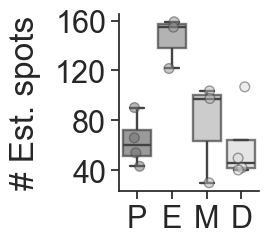

                      sum_sq    df         F    PR(>F)
C(estrous_stage)  729.608904   3.0  7.130011  0.007609
Residual          341.097601  10.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     D      E  19.9763 0.0054   6.3296  33.623   True
     D      M   3.9072 0.8172  -9.7395 17.5539  False
     D      P   7.2678 0.3454  -5.3666 19.9022  False
     E      M -16.0691 0.0305 -30.6581 -1.4802   True
     E      P -12.7085 0.0698 -26.3552  0.9382  False
     M      P   3.3606 0.8732 -10.2861 17.0073  False
-----------------------------------------------------


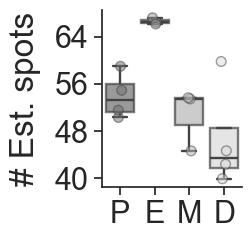

                       sum_sq    df         F    PR(>F)
C(estrous_stage)  1031.595152   3.0  0.679887  0.584128
Residual          5057.676579  10.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     D      E  -2.2136 0.9992 -54.7626 50.3353  False
     D      M  20.5783 0.6416 -31.9706 73.1273  False
     D      P   9.6939 0.9267  -38.957 58.3447  False
     E      M   22.792 0.6168 -33.3852 78.9691  False
     E      P  11.9075 0.8974 -40.6414 64.4564  False
     M      P -10.8845 0.9188 -63.4334 41.6645  False
-----------------------------------------------------


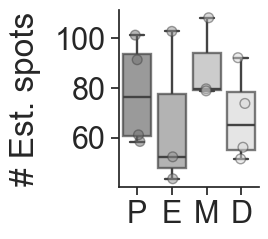

                      sum_sq    df         F    PR(>F)
C(estrous_stage)  110.857841   3.0  3.041317  0.079336
Residual          121.501999  10.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     D      E  -5.0389 0.2902 -13.1837  3.1059  False
     D      M   0.7627 0.9913  -7.3821  8.9075  False
     D      P   2.8753 0.6597  -4.6654 10.4159  False
     E      M   5.8015 0.2375  -2.9056 14.5087  False
     E      P   7.9141 0.0574  -0.2307 16.0589  False
     M      P   2.1126 0.8558  -6.0322 10.2574  False
-----------------------------------------------------


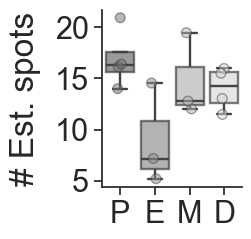

In [11]:
sns.set(style='ticks', font_scale=2)
for channel in channel_mapping.values():
    channel_df = result[result['channel'] == channel]

    model = smf.ols('value ~ C(estrous_stage)', data=channel_df).fit()
    aov_table = sm.stats.anova_lm(model, typ=2)
    print(aov_table)
    mc = pairwise_tukeyhsd(endog=channel_df['value'], groups=channel_df['estrous_stage'], alpha=0.05)
    print(mc.summary())
    


    plt.subplots(figsize=(1.8, 2.3))
    sns.boxplot(x='estrous_stage', y='value', data=channel_df, 
                palette=['#707070', '#939393', '#B7B7B7', '#DBDBDB'], saturation=8, 
                linewidth=1.7, showfliers = False,boxprops=dict(alpha=.7))
    
    sns.stripplot(x='estrous_stage', y='value', data=channel_df,
                  palette=['#707070', '#939393', '#B7B7B7', '#DBDBDB'] , jitter=True, 
                  dodge=False, marker='o', size=7, linewidth=1, 
                  edgecolor='gray', alpha=0.5)
    plt.ylabel('# Est. spots', labelpad=10)
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(4))
    plt.xlabel('')
    sns.despine()


    # plt.savefig(f'{channel}_spot_detection.png', dpi=300, bbox_inches='tight')

    if channel == 'HCN1' or channel == 'HCN2':
        plt.savefig(f'output_figures/{channel}_spot_detection.png', dpi = 300, transparent = True, bbox_inches = 'tight')
        # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{channel}_spot_detection.pdf', dpi=300, bbox_inches='tight', transparent=True)
    else:
        plt.savefig(f'output_figures/{channel}_spot_detection.png', dpi = 300, transparent = True,  bbox_inches = 'tight')
        # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_15/linked_files_figS15/{channel}_spot_detection.pdf', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

In [41]:
unmelted_df = filtered_df.pivot_table(index=['estrous_stage', 'mice_ID', 'Image', 'ROI', 'Centroid X µm', 'Centroid Y µm'], columns='channel', values='value').reset_index().fillna(0)

In [105]:
corrs = pd.DataFrame()
for stage in ['P', 'E', 'M', 'D']:
    stage_df = unmelted_df[unmelted_df['estrous_stage'] == stage]
    for animal in stage_df['mice_ID'].unique():
        animal_df = stage_df[stage_df['mice_ID'] == animal].loc[:, 'HCN1':'HCN4']   
        corr_df = animal_df.corr()
        # Create a mask where the upper triangle including the diagonal is True
        mask = pd.DataFrame(np.triu(np.ones(corr_df.shape, dtype=bool), k=0), index=corr_df.index, columns=corr_df.columns)

        # Apply the mask to set the upper triangle values to NaN
        lower_triangle = corr_df.where(~mask).stack()
    
        lower_triangle.index.names = ['channel1', 'channel2']
        lower_triangle = lower_triangle.reset_index(name='corr')
        lower_triangle['estrous_stage'] = stage
        lower_triangle['mice_ID'] = animal
        corrs = pd.concat([corrs, lower_triangle])



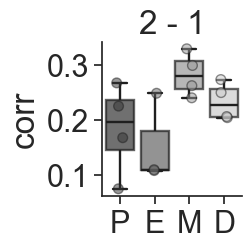

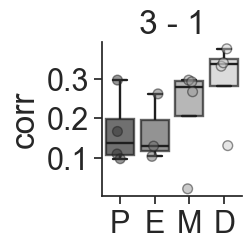

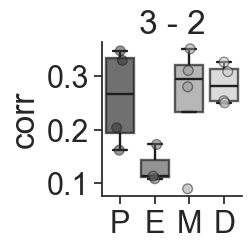

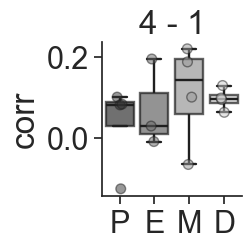

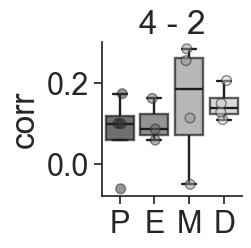

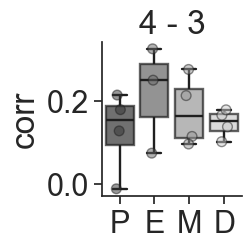

In [107]:
corrs['corr_pair'] = corrs['channel1'] + ' - ' + corrs['channel2']
corrs['corr_pair'] = corrs['corr_pair'].str.replace('HCN', '')
pattern = r'^(\d+)\s*-\s*\1$'

# Filter rows where the 'info' column does not match the pattern
corrs = corrs[~corrs['corr_pair'].str.contains(pattern, regex=True)]


for pair in corrs.corr_pair.unique():
    stage_df = corrs[corrs['corr_pair'] == pair]
    plt.subplots(figsize=(1.8, 2))
    sns.boxplot(x='estrous_stage', y='corr', data=stage_df, palette='gray',
                saturation=8, 
                linewidth=1.7, showfliers = False,boxprops=dict(alpha=.7))
    sns.stripplot(x='estrous_stage', y='corr', data=stage_df,
                 palette = 'gray', jitter=True, 
                  dodge=False, marker='o', size=7, linewidth=1, 
                  edgecolor='gray', alpha=0.5)
    plt.title(pair)
    sns.despine()
    plt.xlabel('')

In [215]:
threshold = filtered_df.groupby([ 'channel'])['value'].quantile(0.5)

In [216]:
threshold

channel
HCN1    58.1669
HCN2    42.2218
HCN3    58.7857
HCN4    12.1383
Name: value, dtype: float64

                     sum_sq    df         F    PR(>F)
C(estrous_stage)  84.487011   3.0  4.424816  0.028472
Residual          70.010974  11.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     D      E  -6.0933 0.0388 -11.8922 -0.2944   True
     D      M  -0.3221 0.9978  -5.6908  5.0467  False
     D      P  -0.1802 0.9996  -5.5489  5.1886  False
     E      M   5.7712 0.0512  -0.0277 11.5701  False
     E      P   5.9131 0.0453   0.1142  11.712   True
     M      P   0.1419 0.9998  -5.2269  5.5106  False
-----------------------------------------------------


Text(0.5, 0, '')

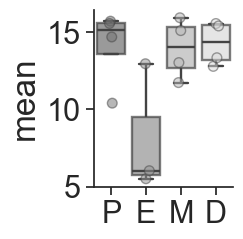

In [226]:
select_channel = 'HCN1'
top_channel_expression = unmelted_df[unmelted_df[select_channel]> threshold[select_channel]]
plt.subplots(figsize=(1.8, 2.3))
channel = 'HCN4'
grouped = top_channel_expression.groupby(([ 'estrous_stage', 'mice_ID']))[channel].mean().reset_index(name = 'mean')

model = smf.ols('mean ~ C(estrous_stage)', data=grouped).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)
mc = pairwise_tukeyhsd(endog=grouped['mean'], groups=grouped['estrous_stage'], alpha=0.05)
print(mc.summary())


sns.boxplot(x='estrous_stage', y='mean', data=grouped, palette=['#707070', '#939393', '#B7B7B7', '#DBDBDB'], 
            saturation=8, linewidth=1.7, showfliers = False,boxprops=dict(alpha=.7), order=['P', 'E', 'M', 'D'])
sns.stripplot(x='estrous_stage', y='mean', data=grouped, palette=['#707070', '#939393', '#B7B7B7', '#DBDBDB'] , 
              jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, order=['P', 'E', 'M', 'D'])
sns.despine()
plt.xlabel('')

In [222]:
top_channel_expression = unmelted_df[(unmelted_df['HCN1']> threshold['HCN1']) &
                                     (unmelted_df['HCN2']> threshold['HCN2']) ]

count = top_channel_expression.groupby(['estrous_stage', 'mice_ID'])['Image'].count().reset_index()
total = unmelted_df.groupby(['estrous_stage', 'mice_ID'])['Image'].count().reset_index()
count['percentage'] = count['Image'] / total['Image'] * 100

Text(0.5, 0, '')

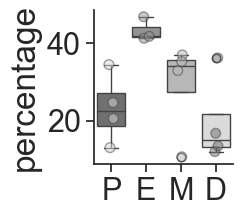

In [223]:
plt.subplots(figsize=(1.8, 2))
sns.boxplot(x='estrous_stage', 
            y='percentage', 
            data=count, 
            palette=['#707070', '#939393', '#B7B7B7', '#DBDBDB'],
            order = ['P', 'E', 'M', 'D'])
sns.stripplot(x='estrous_stage',
               y='percentage', 
               data=count, 
               palette=['#707070', '#939393', '#B7B7B7', '#DBDBDB'], 
               jitter=True, 
               dodge=False, 
               marker='o', 
               size=7, 
               linewidth=1, 
               edgecolor='gray', 
               alpha=0.5)
sns.despine()
plt.xlabel('')

# filter out low intensity spot

In [41]:
detections = pd.read_csv('all_detection_results 2.csv')
kept_spot_measurements = 'Mean channel intensity'
individual_spot_detection = detections[(detections['Name']!= 'PathCellObject')]
individual_spot_detection['channel'] = individual_spot_detection['measuremnt'].str.extract(r'Channel (\d)')
channel_mapping = {'2': 'HCN1', '3': 'HCN2', '4': 'HCN3', '5': 'HCN4'}
individual_spot_detection['channel'] = individual_spot_detection['channel'].map(channel_mapping)

In [79]:
individual_spot_detection['mice_ID'] = individual_spot_detection['Image'].str.split('_').str[0].str.lower()
merged_df = pd.merge(individual_spot_detection, estrous_df, on='mice_ID', how='left')

In [69]:
filter_threshold_mapping = {'HCN1': 0,'HCN2':0,  'HCN3': 0, 'HCN4': 0}
# filter_threshold_mapping = {'HCN1': 0.1, 'HCN2': 0.488, 'HCN3': 0.2, 'HCN4': 0.344}
individual_spot_detection['filter_threshold'] = individual_spot_detection['channel'].map(filter_threshold_mapping)

In [70]:
num_spots = individual_spot_detection[individual_spot_detection['measuremnt'] == 'Num spots']
num_spots.drop(['channel', 'filter_threshold'], axis=1, inplace=True)
num_spots = num_spots.pivot_table(index=['Image', 'Name', 'Class', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm'], columns='measuremnt', values='value').reset_index()

In [71]:
filtered_individual_spot_detection = individual_spot_detection[(individual_spot_detection['measuremnt'].str.contains(kept_spot_measurements)) &
                                                                (individual_spot_detection['value'] > individual_spot_detection['filter_threshold'])]

In [72]:
merged_df = pd.merge(filtered_individual_spot_detection, num_spots, on=['Image', 'Name', 'Class', 'Parent','ROI', 'Centroid X µm', 'Centroid Y µm'], how='left')
merged_df['mice_ID'] = merged_df['Image'].str.split('_').str[0].str.lower()
merged_with_estrous = pd.merge(merged_df, estrous_df, on='mice_ID', how='left')
result = merged_with_estrous.groupby(['estrous_stage', 'mice_ID' ,'channel'])['Num spots'].sum().reset_index()

In [73]:
num_spots['channel_number'] = num_spots['Class'].str.extract(r'Channel (\d)')
num_spots['channel'] = num_spots['channel_number'].map(channel_mapping)
num_spots['mice_ID'] = num_spots['Image'].str.split('_').str[0].str.lower()
# num_spots = num_spots[num_spots['Parent'] != 'Medial preoptic nucleus']
grouped_spots = num_spots.groupby(['mice_ID', 'channel'])['Num spots'].count().reset_index(name = 'count')

In [74]:
result_merged = pd.merge(result, grouped_spots, on=['mice_ID', 'channel'], how='left')
result_merged.rename(columns={'Num spots': 'num_spots'}, inplace=True)
result_merged['spot_per_cell'] = result_merged['num_spots'] / result_merged['count']
result_merged['estrous_stage'] = pd.Categorical(result_merged['estrous_stage'], categories=['P', 'E', 'M', 'D'], ordered=True)

In [75]:
result_merged[result_merged['channel'] == 'HCN1']

,estrous_stage,mice_ID,channel,num_spots,count,spot_per_cell
0,D,brac8916.7c,HCN1,2.947169e+05,39174,7.523277
4,D,brac9252.4h,HCN1,1.575176e+06,59530,26.460208
8,D,brac9539.2g,HCN1,3.548981e+05,46666,7.605068
12,D,brac9660.1h,HCN1,5.202379e+04,3583,14.519619
16,E,brac8886.8h,HCN1,3.208281e+05,23826,13.465463
20,E,brac9098.5i,HCN1,1.953076e+06,65183,29.962963
24,E,bryd93.3f,HCN1,1.505176e+05,10442,14.414634
28,M,brac8257.7c,HCN1,1.037896e+06,85603,12.124534
32,M,brac8916.7b,HCN1,6.874709e+05,52215,13.166157
36,M,brac9366.3f,HCN1,1.217793e+05,17703,6.879023


                            OLS Regression Results                            
Dep. Variable:          spot_per_cell   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     1.631
Date:                Thu, 07 Nov 2024   Prob (F-statistic):              0.239
Time:                        18:31:39   Log-Likelihood:                -46.755
No. Observations:                  15   AIC:                             101.5
Df Residuals:                      11   BIC:                             104.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 9.04

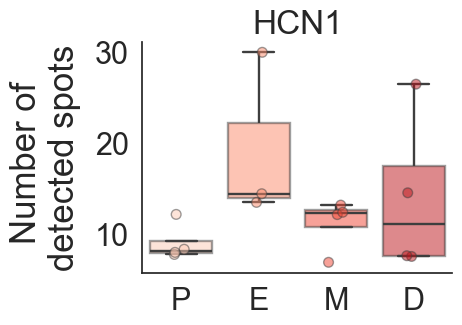

                            OLS Regression Results                            
Dep. Variable:          spot_per_cell   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     1.106
Date:                Thu, 07 Nov 2024   Prob (F-statistic):              0.388
Time:                        18:31:39   Log-Likelihood:                -38.586
No. Observations:                  15   AIC:                             85.17
Df Residuals:                      11   BIC:                             88.00
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.64

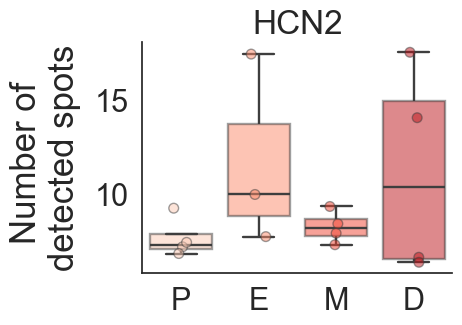

                            OLS Regression Results                            
Dep. Variable:          spot_per_cell   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                 -0.027
Method:                 Least Squares   F-statistic:                    0.8768
Date:                Thu, 07 Nov 2024   Prob (F-statistic):              0.483
Time:                        18:31:39   Log-Likelihood:                -47.527
No. Observations:                  15   AIC:                             103.1
Df Residuals:                      11   BIC:                             105.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                10.72

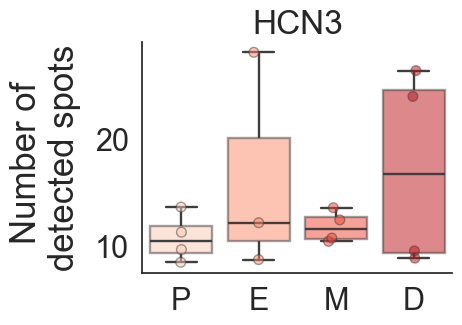

                            OLS Regression Results                            
Dep. Variable:          spot_per_cell   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                 -0.184
Method:                 Least Squares   F-statistic:                    0.2736
Date:                Thu, 07 Nov 2024   Prob (F-statistic):              0.843
Time:                        18:31:39   Log-Likelihood:                -38.039
No. Observations:                  15   AIC:                             84.08
Df Residuals:                      11   BIC:                             86.91
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 7.86

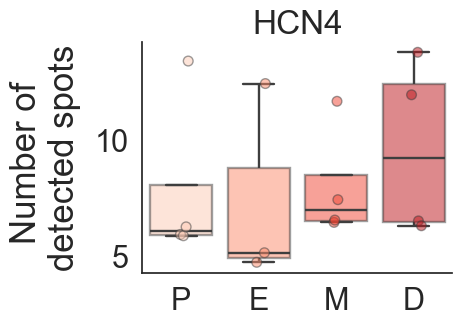

In [76]:

sns.set(style='white', font_scale=2)
for channel in channel_mapping.values():
    channel_df = result_merged[result_merged['channel'] == channel]

    model = smf.ols('spot_per_cell ~ C(estrous_stage)', data=channel_df).fit()
    print(model.summary())


    plt.subplots(figsize=(4, 3))
    sns.boxplot(x='estrous_stage', y='spot_per_cell', data=channel_df, 
                palette='Reds', saturation=8, 
                linewidth=1.7, showfliers = False,boxprops=dict(alpha=.5))
    sns.stripplot(x='estrous_stage', y='spot_per_cell', data=channel_df,
                  palette= 'Reds', jitter=True, 
                  dodge=False, marker='o', size=7, linewidth=1, 
                  edgecolor='gray', alpha=0.5)
    plt.ylabel('Number of \ndetected spots', labelpad=10, fontsize = 25)
    plt.xlabel('')
    plt.title(channel)
    sns.despine()
    plt.savefig(f'{channel}_spot_detection.png', dpi=300, bbox_inches='tight')
    plt.show()

# additional visualization for support 

In [38]:
E2_df = pd.read_excel('/Users/caom/Downloads/41586_2022_4686_MOESM3_ESM.xlsx')
E2_df['neg_log_pvalue'] = -np.log10(E2_df['p-value'])
E2_df['log2_FC'] = np.log2(E2_df['Fold'])


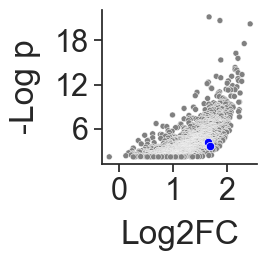

In [45]:
# Set thresholds
pvalue_threshold = 0.05
sns.style = 'ticks'
from matplotlib.ticker import MaxNLocator

# Creating the plot
plt.figure(figsize=(2, 2))
sns.scatterplot(data=E2_df, x='log2_FC', y='neg_log_pvalue', color='gray', size=5)

# Highlighting significant points
# Significant by p-value
significant_pvalue = E2_df['p-value'] < pvalue_threshold

hcn_genes = ['Hcn1', 'Hcn2', 'Hcn3', 'Hcn4']
filtered_df = E2_df[E2_df['Gene annotation'].isin(hcn_genes)]
sns.scatterplot(data=filtered_df, x='log2_FC', y='neg_log_pvalue', color='blue')


# for i in filtered_df.index:
#      print(filtered_df['log2_FC'][i], filtered_df['neg_log_pvalue'][i], filtered_df['Gene annotation'][i])
#      plt.text(filtered_df['log2_FC'][i], filtered_df['neg_log_pvalue'][i], filtered_df['Gene annotation'][i], fontsize=10)

# remove legend
plt.legend().remove()

# set xticks and yticks maxlocator
ax = plt.gca()  # Get the current axes
ax.xaxis.set_major_locator(MaxNLocator(3))
ax.yaxis.set_major_locator(MaxNLocator(4))

# Applying colors

plt.xlabel('Log2FC',labelpad=10)
plt.ylabel('-Log p', labelpad=10)


sns.despine()
plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_15/linked_files_figS15/hcn_volcano_plot.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

